# Load Preprocessed Data

(303, 14)
Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Total missing values: 6
Missing values after imputation: 0
Categorical columns: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Data types:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target      float64
dtype: object
Categorical columns: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Numerical columns: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Shape after encoding: (303, 21)
New columns created:
['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'target', 'sex_1.0', 'cp_2.0', 'cp_3.0', 'cp_4

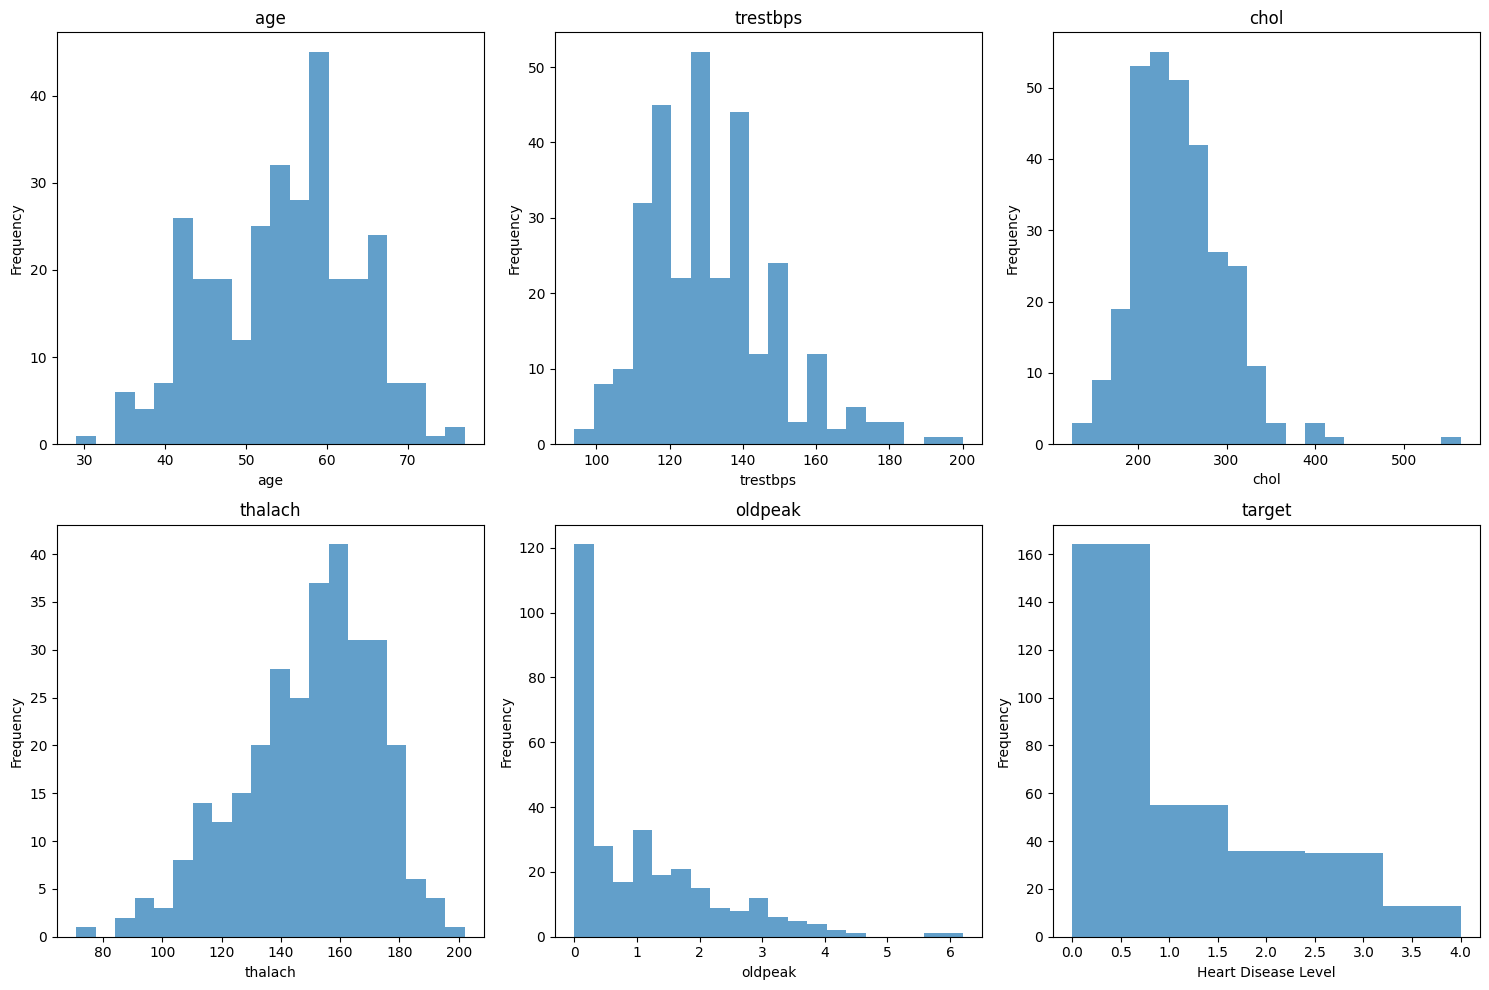

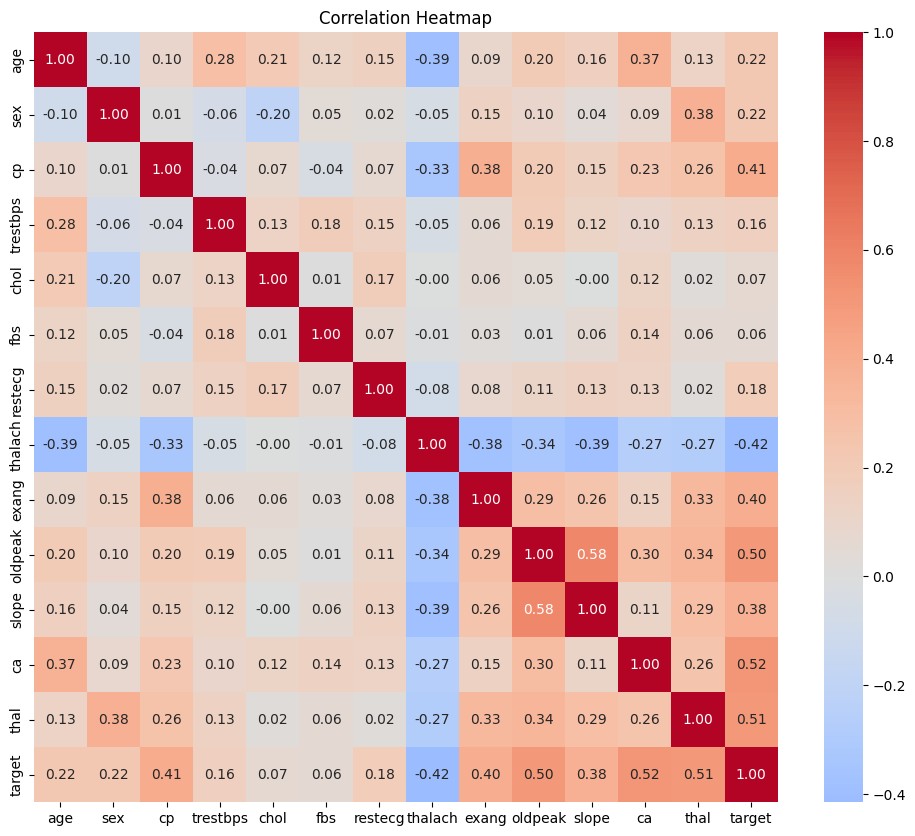

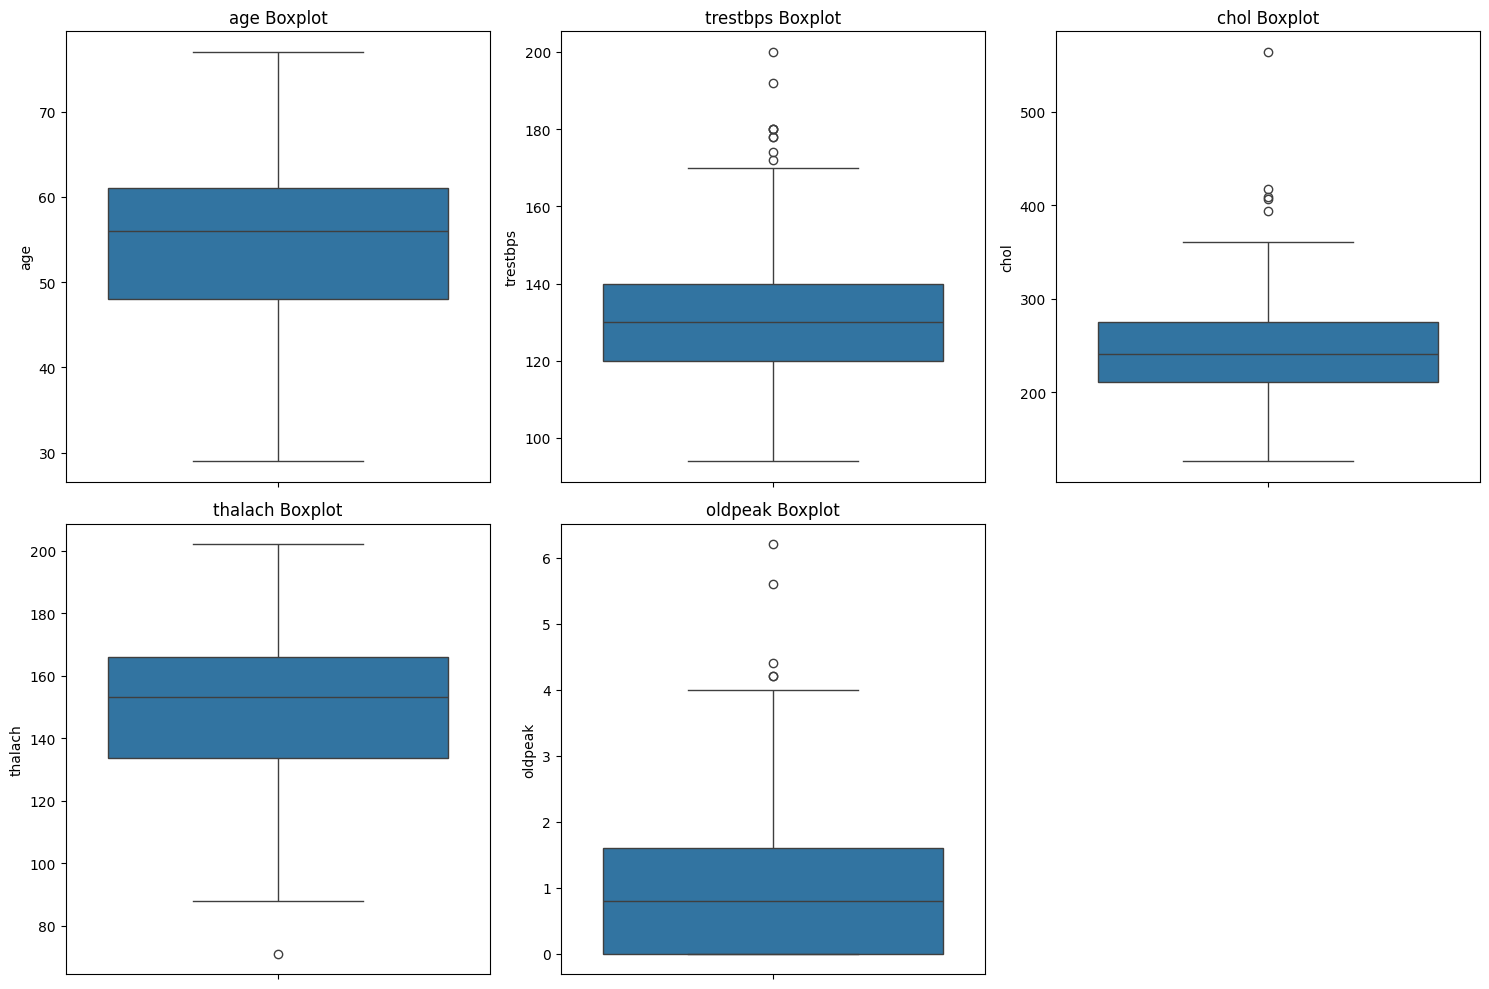

Standardized features shape: (303, 20)
Number of features: 20
Target shape: (303,)


In [8]:
%run " 01_data_preprocessing.ipynb"

print(f"Standardized features shape: {X_scaled.shape}")
print(f"Number of features: {X_scaled.shape[1]}")
print(f"Target shape: {y.shape}")

# Apply PCA for Dimensionality Reduction

In [9]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)
print(f"PCA-transformed dataset shape: {X_pca.shape}")
print(f"Number of components: {pca.n_components_}")

PCA-transformed dataset shape: (303, 20)
Number of components: 20


# Calculate Explained Variance Ratio

In [10]:
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

print("Explained variance ratio per component:")
for i, ratio in enumerate(explained_variance_ratio[:10]):
    print(f"PC{i+1}: {ratio:.4f}")
    
print(f"\nCumulative variance explained by first 10 components: {cumulative_variance[9]:.4f}")

Explained variance ratio per component:
PC1: 0.2673
PC2: 0.1574
PC3: 0.1215
PC4: 0.1080
PC5: 0.0696
PC6: 0.0480
PC7: 0.0349
PC8: 0.0326
PC9: 0.0283
PC10: 0.0252

Cumulative variance explained by first 10 components: 0.8928


# Determine Optimal Number of Components

In [11]:
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1

print(f"Components needed for 95% variance: {n_components_95}")
print(f"Components needed for 90% variance: {n_components_90}")
print(f"Variance explained by {n_components_95} components: {cumulative_variance[n_components_95-1]:.4f}")
print(f"Variance explained by {n_components_90} components: {cumulative_variance[n_components_90-1]:.4f}")

Components needed for 95% variance: 13
Components needed for 90% variance: 11
Variance explained by 13 components: 0.9514
Variance explained by 11 components: 0.9151


# Visualize Cumulative Variance Plot

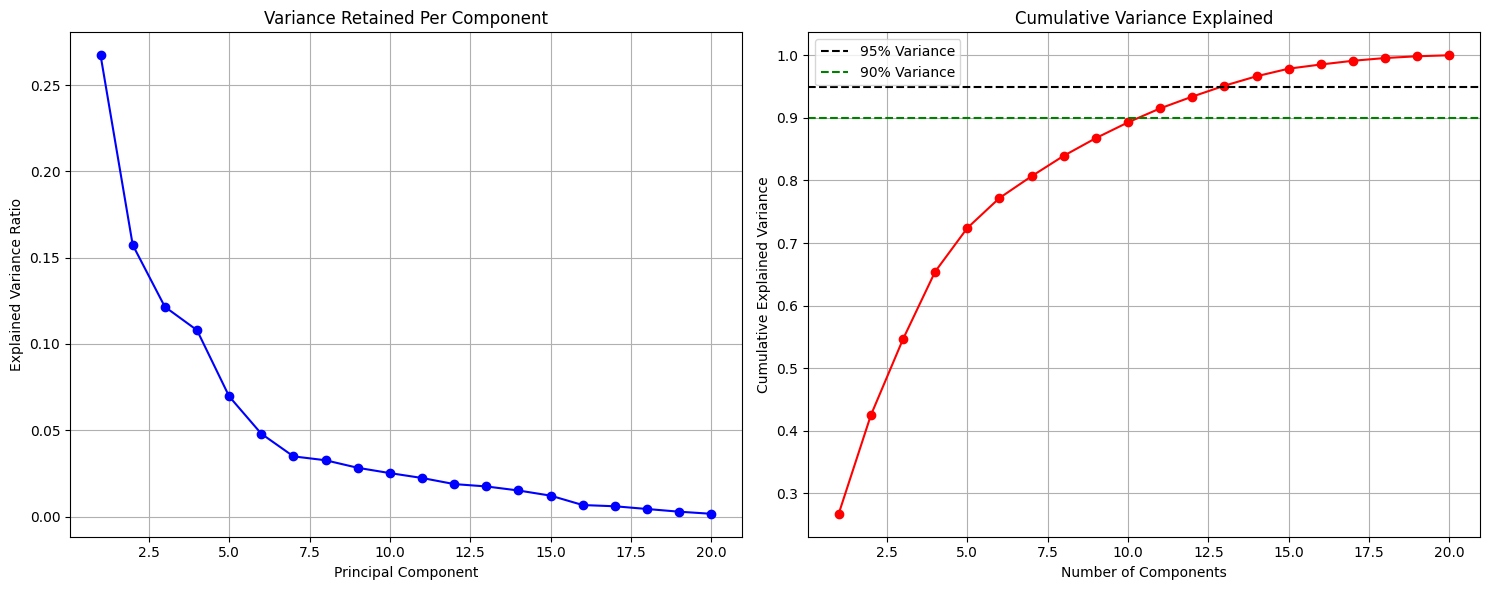

In [12]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.plot(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, 'bo-')
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance Ratio')
ax1.set_title('Variance Retained Per Component')
ax1.grid(True)

ax2.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'ro-')
ax2.axhline(y=0.95, color='k', linestyle='--', label='95% Variance')
ax2.axhline(y=0.90, color='g', linestyle='--', label='90% Variance')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Explained Variance')
ax2.set_title('Cumulative Variance Explained')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# PCA Scatter Plot Visualization

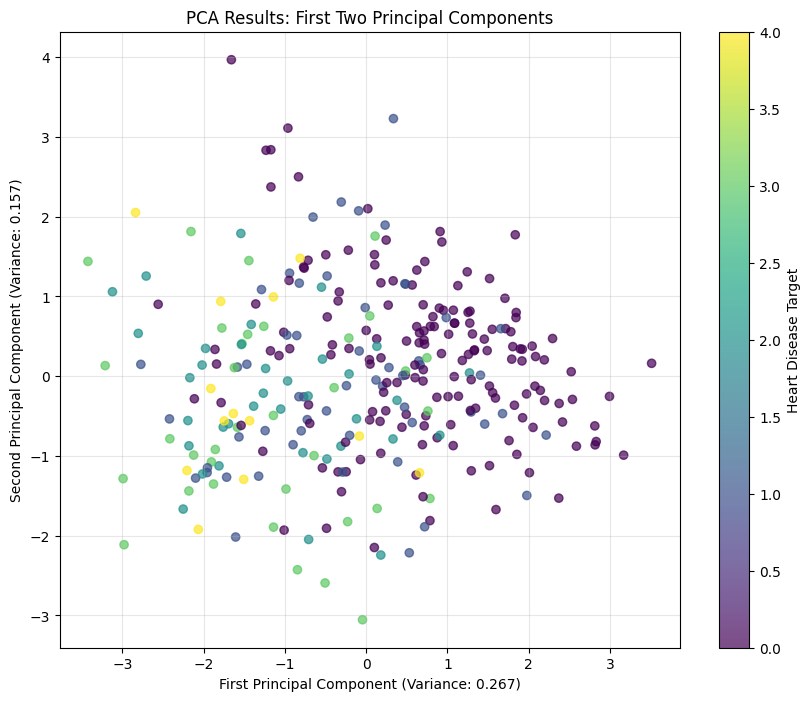

In [13]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.7)
plt.xlabel(f'First Principal Component (Variance: {explained_variance_ratio[0]:.3f})')
plt.ylabel(f'Second Principal Component (Variance: {explained_variance_ratio[1]:.3f})')
plt.title('PCA Results: First Two Principal Components')
plt.colorbar(scatter, label='Heart Disease Target')
plt.grid(True, alpha=0.3)
plt.show()

# Create PCA-Transformed Dataset

In [14]:
pca_optimal = PCA(n_components=n_components_95)
X_pca_optimal = pca_optimal.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca_optimal, columns=[f'PC{i+1}' for i in range(n_components_95)])
pca_df['target'] = y.values

print(f"PCA-transformed dataset shape: {pca_df.shape}")
print(f"Variance retained: {cumulative_variance[n_components_95-1]:.4f}")
print("\nPCA-transformed dataset:")
print(pca_df.head())

PCA-transformed dataset shape: (303, 14)
Variance retained: 0.9514

PCA-transformed dataset:
        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0 -1.072490  0.258394  1.037182 -0.119774  0.953289 -0.168047 -0.151114   
1 -2.804616  0.536802  0.003767 -0.617366 -0.979691 -0.090323 -0.259099   
2 -1.957112 -1.208116 -0.428867  0.056204  0.846473  0.874964 -0.066097   
3  1.135660 -0.251109  1.406952  2.691248  1.082938 -0.893851  0.210580   
4  1.591257 -0.273598  0.984122  0.735972  0.129932 -0.368240 -0.827301   

        PC8       PC9      PC10      PC11      PC12      PC13  target  
0  0.520553 -1.032009 -0.042051 -0.232873  0.586556  0.101403     0.0  
1  0.358687 -0.161476  0.112805 -0.161623  0.408115  0.413059     2.0  
2  0.304299  0.241857  0.124506 -0.386049  0.130411 -0.373702     1.0  
3 -0.248456 -0.390239 -0.400314  0.143627  0.169677  0.383118     0.0  
4  0.489760 -0.393350  0.433480  0.376107 -0.391069 -0.582531     0.0  
